# Semana 3 — Baseline + Modelos Reales

**Objetivo:** Entrenar tres modelos en orden creciente de complejidad,  
compararlos con las métricas correctas y entender qué está aprendiendo cada uno.

**Orden del día:**
1. Logistic Regression — baseline interpretable
2. Random Forest — modelo de ensemble
3. Tabla comparativa de métricas
4. Curvas ROC y Precision-Recall



---

## 0. Cargar datos de semana 2

In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, f1_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

X_train     = joblib.load('X_train.pkl')
X_test      = joblib.load('X_test.pkl')
y_train     = joblib.load('y_train.pkl')
y_test      = joblib.load('y_test.pkl')
preprocessor = joblib.load('preprocessor.pkl')

print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')
print(f'Churn en train: {y_train.mean():.1%}  |  Churn en test: {y_test.mean():.1%}')

Train: 5,634 filas  |  Test: 1,409 filas
Churn en train: 26.5%  |  Churn en test: 26.5%


In [2]:
# Modelo "tonto": predice siempre No Churn
y_pred_tonto = np.zeros(len(y_test), dtype=int)

accuracy_tonto = (y_pred_tonto == y_test).mean()
churn_detectado = (y_pred_tonto[y_test == 1] == 1).mean()

print('=== Modelo que predice SIEMPRE "No Churn" ===')
print(f'Accuracy:          {accuracy_tonto:.1%}  ← parece bueno')
print(f'Churns detectados: {churn_detectado:.1%}  ← inútil')
print()
print('Conclusión: un modelo con 73% de accuracy puede no detectar NINGÚN churn.')
print('Por eso usaremos AUC-ROC, F1-score y Precision-Recall.')

=== Modelo que predice SIEMPRE "No Churn" ===
Accuracy:          73.5%  ← parece bueno
Churns detectados: 0.0%  ← inútil

Conclusión: un modelo con 73% de accuracy puede no detectar NINGÚN churn.
Por eso usaremos AUC-ROC, F1-score y Precision-Recall.


---
## 2. Modelo 1 — Logistic Regression (baseline)

In [3]:
# Pipeline completo: preprocessor + modelo
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # ajusta automáticamente por el desbalance
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)

y_pred_lr    = pipe_lr.predict(X_test)
y_proba_lr   = pipe_lr.predict_proba(X_test)[:, 1]  # probabilidad de churn

auc_lr  = roc_auc_score(y_test, y_proba_lr)
prauc_lr = average_precision_score(y_test, y_proba_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print(f'=== Logistic Regression ===')
print(f'AUC-ROC:  {auc_lr:.4f}')
print(f'PR-AUC:   {prauc_lr:.4f}')
print(f'F1-score: {f1_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
AUC-ROC:  0.8465
PR-AUC:   0.6638
F1-score: 0.6186

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



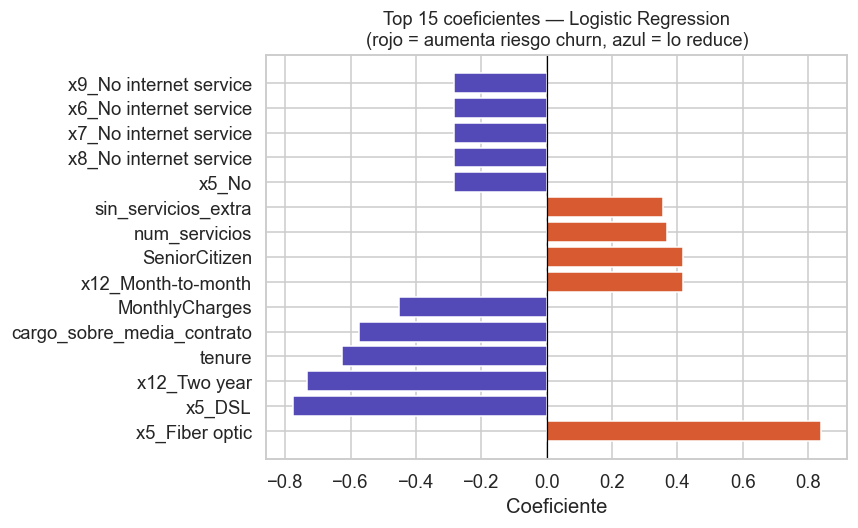

In [4]:
# Coeficientes: qué variables impulsan más el churn según LR
# Primero necesitamos los nombres de features tras el Pipeline
ohe_cols = (pipe_lr.named_steps['preprocessor']
            .named_transformers_['cat']['onehot']
            .get_feature_names_out())

import json
# Si tienes feature_config.json súbelo también; si no, usamos los nombres hardcodeados
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges',
                    'cargo_por_mes', 'num_servicios', 'cargo_sobre_media_contrato']
binary_created   = ['es_cliente_nuevo', 'sin_servicios_extra',
                    'contrato_mensual', 'SeniorCitizen']

feature_names = numeric_features + list(ohe_cols) + binary_created
coefs = pipe_lr.named_steps['classifier'].coef_[0]

coef_df = (pd.DataFrame({'feature': feature_names, 'coef': coefs})
           .reindex(pd.Series(np.abs(coefs)).sort_values(ascending=False).index)
           .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#D85A30' if c > 0 else '#534AB7' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 coeficientes — Logistic Regression\n(rojo = aumenta riesgo churn, azul = lo reduce)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.savefig('plot_08_coeficientes_lr.png', bbox_inches='tight')
plt.show()

---
## 3. Modelo 2 — Random Forest

In [5]:
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,      # número de árboles
        max_depth=8,           # profundidad máxima para evitar overfitting
        min_samples_leaf=20,   # mínimo de muestras por hoja (regularización)
        class_weight='balanced',
        random_state=42,
        n_jobs=-1              # usar todos los núcleos disponibles
    ))
])

pipe_rf.fit(X_train, y_train)

y_pred_rf  = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

auc_rf   = roc_auc_score(y_test, y_proba_rf)
prauc_rf = average_precision_score(y_test, y_proba_rf)
f1_rf    = f1_score(y_test, y_pred_rf)

print(f'=== Random Forest ===')
print(f'AUC-ROC:  {auc_rf:.4f}')
print(f'PR-AUC:   {prauc_rf:.4f}')
print(f'F1-score: {f1_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

=== Random Forest ===
AUC-ROC:  0.8456
PR-AUC:   0.6606
F1-score: 0.6396

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



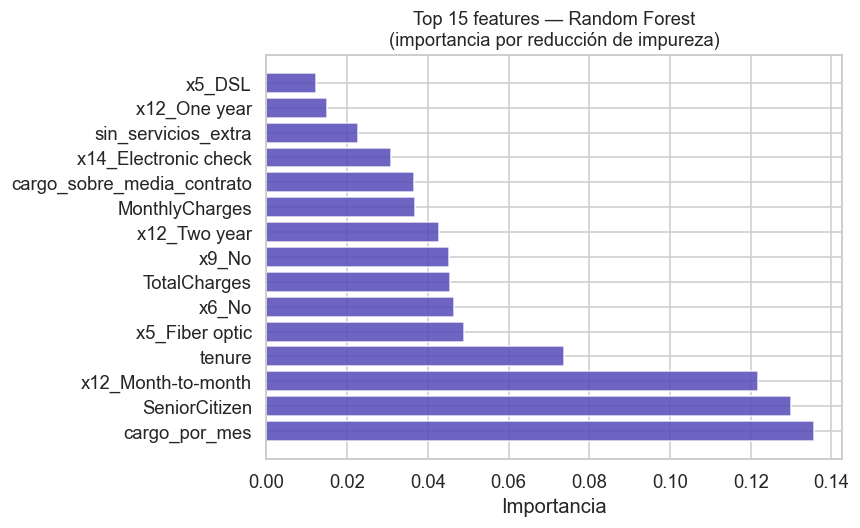

In [6]:
# Feature importance de Random Forest
importances = pipe_rf.named_steps['classifier'].feature_importances_
imp_df = (pd.DataFrame({'feature': feature_names, 'importance': importances})
          .sort_values('importance', ascending=False)
          .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'], imp_df['importance'],
        color='#534AB7', edgecolor='white', alpha=0.85)
ax.set_title('Top 15 features — Random Forest\n(importancia por reducción de impureza)', fontsize=12)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('plot_09_importancia_rf.png', bbox_inches='tight')
plt.show()

---
## 4. Tabla comparativa de modelos

In [9]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

resultados = pd.DataFrame([
    {
        'Modelo': 'Dummy (baseline)',
        'AUC-ROC': 0.500,
        'PR-AUC':  round(y_test.mean(), 4),
        'F1':      0.000,
        'Precision': 0.000,
        'Recall':  0.000,
        'Accuracy': round((1 - y_test.mean()), 4)
    },
    {
        'Modelo': 'Logistic Regression',
        'AUC-ROC': round(auc_lr, 4),
        'PR-AUC':  round(prauc_lr, 4),
        'F1':      round(f1_lr, 4),
        'Precision': round(precision_score(y_test, y_pred_lr), 4),
        'Recall':   round(recall_score(y_test, y_pred_lr), 4),
        'Accuracy': round(accuracy_score(y_test, y_pred_lr), 4)
    },
    {
        'Modelo': 'Random Forest',
        'AUC-ROC': round(auc_rf, 4),
        'PR-AUC':  round(prauc_rf, 4),
        'F1':      round(f1_rf, 4),
        'Precision': round(precision_score(y_test, y_pred_rf), 4),
        'Recall':   round(recall_score(y_test, y_pred_rf), 4),
        'Accuracy': round(accuracy_score(y_test, y_pred_rf), 4)
    },
])

print('=== TABLA COMPARATIVA ===')
print(resultados.to_string(index=False))
print()
print('→ Columnas a mirar: AUC-ROC y F1 (no Accuracy)')
print('→ El dummy tiene AUC=0.5 por definición — cualquier modelo debe superarlo')

=== TABLA COMPARATIVA ===
             Modelo  AUC-ROC  PR-AUC     F1  Precision  Recall  Accuracy
   Dummy (baseline)   0.5000  0.2654 0.0000     0.0000  0.0000    0.7346
Logistic Regression   0.8465  0.6638 0.6186     0.5077  0.7914    0.7410
      Random Forest   0.8456  0.6606 0.6396     0.5330  0.7995    0.7608

→ Columnas a mirar: AUC-ROC y F1 (no Accuracy)
→ El dummy tiene AUC=0.5 por definición — cualquier modelo debe superarlo


---
## 5. Curvas ROC y Precision-Recall

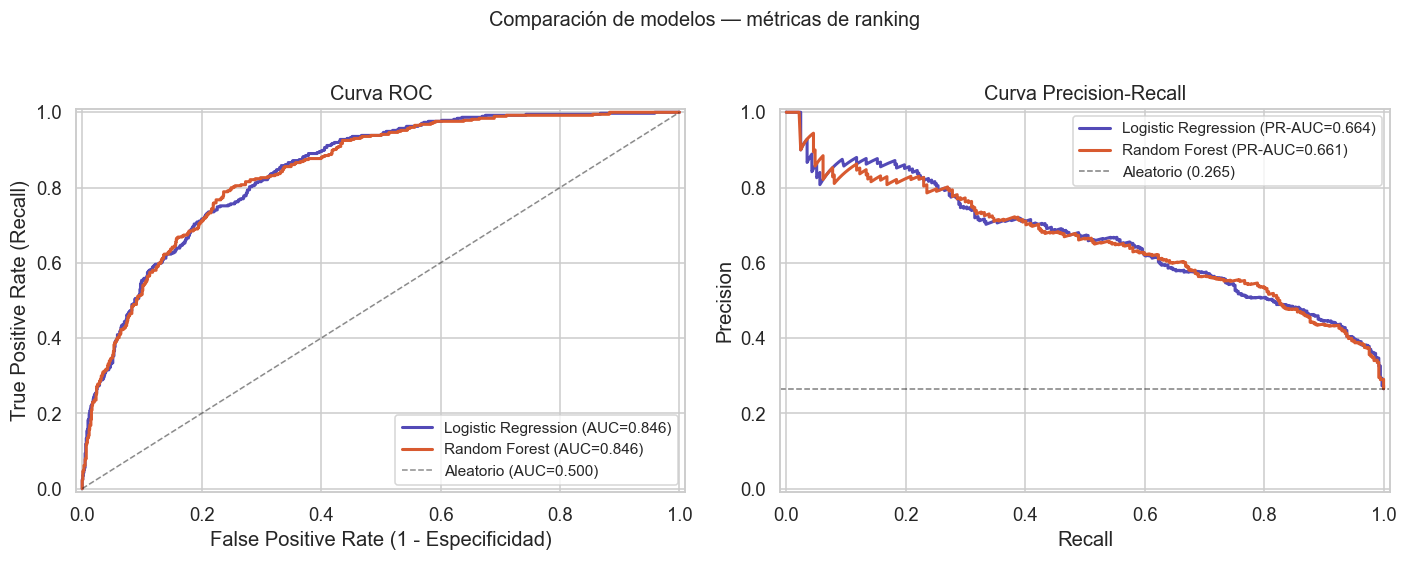

→ La curva ROC mide separación general entre clases
→ La curva PR es más exigente con clases desbalanceadas — mírala con más atención


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Curva ROC ──
ax = axes[0]
for name, y_proba, color in [
    ('Logistic Regression', y_proba_lr, '#534AB7'),
    ('Random Forest',       y_proba_rf, '#D85A30'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio (AUC=0.500)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.03, color='gray')
ax.set_xlabel('False Positive Rate (1 - Especificidad)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Curva ROC', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

# ── Curva Precision-Recall ──
ax = axes[1]
for name, y_proba, color in [
    ('Logistic Regression', y_proba_lr, '#534AB7'),
    ('Random Forest',       y_proba_rf, '#D85A30'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    prauc_val = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{name} (PR-AUC={prauc_val:.3f})')

baseline_pr = y_test.mean()
ax.axhline(baseline_pr, color='black', linestyle='--', linewidth=1,
           alpha=0.5, label=f'Aleatorio ({baseline_pr:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.suptitle('Comparación de modelos — métricas de ranking', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_10_curvas_roc_pr.png', bbox_inches='tight')
plt.show()

print('→ La curva ROC mide separación general entre clases')
print('→ La curva PR es más exigente con clases desbalanceadas — mírala con más atención')

---
## 6. Matrices de confusión

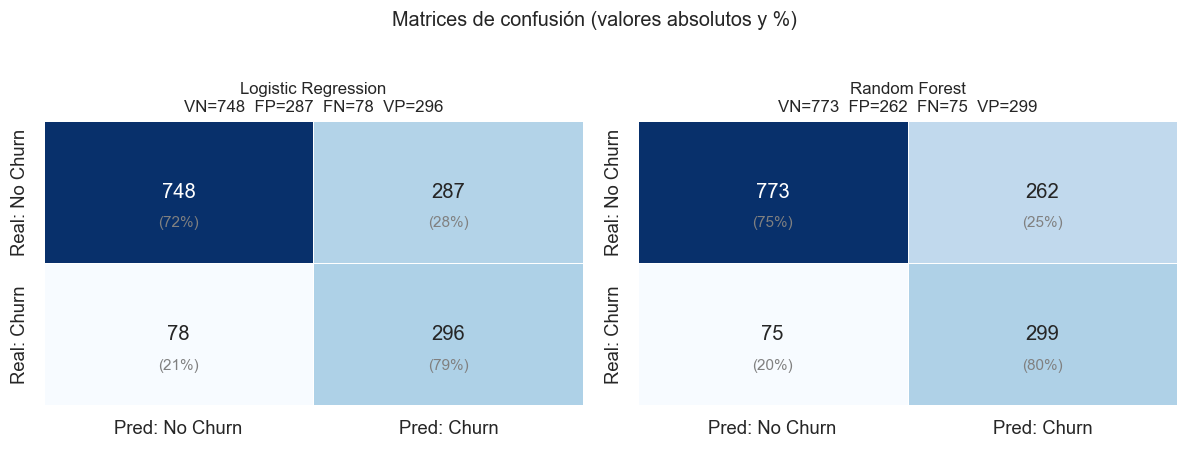

Leyenda:
  VN (Verdadero Negativo) = cliente que NO se iba y el modelo dijo que NO
  VP (Verdadero Positivo) = cliente que SÍ se iba y el modelo lo detectó
  FP (Falso Positivo)     = cliente que NO se iba pero el modelo lo marcó como riesgo
  FN (Falso Negativo)     = cliente que SÍ se iba pero el modelo NO lo detectó ← el más costoso


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf)
]):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['Pred: No Churn', 'Pred: Churn'],
                yticklabels=['Real: No Churn', 'Real: Churn'],
                cbar=False)

    # Añadir % sobre cada celda
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'({cm_pct[i,j]:.0%})',
                    ha='center', va='center', fontsize=10, color='gray')

    ax.set_title(f'{name}\nVN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  VP={cm[1,1]}',
                 fontsize=11)

plt.suptitle('Matrices de confusión (valores absolutos y %)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_11_confusion_matrices.png', bbox_inches='tight')
plt.show()

print('Leyenda:')
print('  VN (Verdadero Negativo) = cliente que NO se iba y el modelo dijo que NO')
print('  VP (Verdadero Positivo) = cliente que SÍ se iba y el modelo lo detectó')
print('  FP (Falso Positivo)     = cliente que NO se iba pero el modelo lo marcó como riesgo')
print('  FN (Falso Negativo)     = cliente que SÍ se iba pero el modelo NO lo detectó ← el más costoso')

---
## 7. Diagnóstico de overfitting



In [12]:
for name, pipe in [('Logistic Regression', pipe_lr), ('Random Forest', pipe_rf)]:
    auc_train = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    auc_test  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:, 1])
    gap = auc_train - auc_test
    estado = 'OK' if gap < 0.03 else ('LEVE OVERFITTING' if gap < 0.07 else 'OVERFITTING')
    print(f'{name}')
    print(f'  AUC train: {auc_train:.4f}  |  AUC test: {auc_test:.4f}  |  GAP: {gap:.4f}  → {estado}')
    print()

print('Regla práctica: gap > 0.05 en AUC merece investigación')
print('Soluciones habituales: aumentar min_samples_leaf, reducir max_depth, más datos')

Logistic Regression
  AUC train: 0.8528  |  AUC test: 0.8465  |  GAP: 0.0063  → OK

Random Forest
  AUC train: 0.8800  |  AUC test: 0.8456  |  GAP: 0.0344  → LEVE OVERFITTING

Regla práctica: gap > 0.05 en AUC merece investigación
Soluciones habituales: aumentar min_samples_leaf, reducir max_depth, más datos


---
## 8. Guardar modelos para semanas siguientes

In [13]:
joblib.dump(pipe_lr, 'pipeline_lr.pkl')
joblib.dump(pipe_rf, 'pipeline_rf.pkl')

# Guardar también las probabilidades para las curvas de semana 6
import numpy as np
np.save('y_proba_lr.npy', y_proba_lr)
np.save('y_proba_rf.npy', y_proba_rf)

print('Modelos guardados: pipeline_lr.pkl, pipeline_rf.pkl')
print('Probabilidades guardadas: y_proba_lr.npy, y_proba_rf.npy')

Modelos guardados: pipeline_lr.pkl, pipeline_rf.pkl
Probabilidades guardadas: y_proba_lr.npy, y_proba_rf.npy


In [ ]:
import os
archivos = ['pipeline_lr.pkl', 'pipeline_rf.pkl', 'y_proba_lr.npy', 'y_proba_rf.npy']
for fname in archivos:
    existe = os.path.exists(fname)
    print(f'{fname}: {"✅ Encontrado" if existe else "❌ NO encontrado"}')
print('Verificación de archivos completada.')
